<div style="background:linear-gradient(135deg,#061A33 0%,#0B2E59 45%,#00A6C0 100%); padding:44px 36px; border-radius:18px; color:#F4FBFF; font-family:'Segoe UI',Tahoma,sans-serif; box-shadow:0 8px 30px rgba(0,0,0,0.25);">
  <div style="font-size:12px; letter-spacing:4px; text-transform:uppercase; opacity:0.75; margin-bottom:10px;">BinX Tech &nbsp;•&nbsp; AI &amp; Machine Learning Internship &nbsp;•&nbsp; Phase 3 Capstone</div>
  <div style="font-size:38px; font-weight:800; line-height:1.15;">🩺 Week 8 · Day 3</div>
  <div style="font-size:22px; font-weight:400; opacity:0.92; margin-top:4px;">Computer Vision Preprocessing — OpenCV on Real 12-Lead ECG Scans</div>
  <div style="margin-top:20px; display:flex; flex-wrap:wrap; gap:8px;">
    <span style="background:#00C2D1; color:#04263A; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">🚀 SPRINT 3 — DAY 3 / 5</span>
    <span style="background:#FFC857; color:#4A3400; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">⏱️ 8 HOURS</span>
    <span style="background:#8CE99A; color:#0B3D1E; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">🖼️ IMAGE PREPROCESSING</span>
    <span style="background:#D0BFFF; color:#2E1065; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">❤️ CARDIAC MONITORING THREAD</span>
  </div>
</div>

<div style="text-align:center; color:#7C8B9B; font-size:13px; font-style:italic; margin-top:14px;">
"A model never sees a photo — it sees a grid of numbers. Get the grid wrong and nothing after it can be trusted."
</div>

<div style="border-left:5px solid #00A6C0; background:#F0FBFD; padding:18px 22px; border-radius:0 10px 10px 0; margin:18px 0;">
<h3 style="margin-top:0; color:#0B2E59;">📖 The Story So Far</h3>
<p style="margin-bottom:0; color:#233; line-height:1.6;">
Day 2 turned clean text into numbers and picked the representation that fit the job. Day 3 switches modality
entirely: <b>images</b> — and for the first time this sprint, the images are not a borrowed dataset. This notebook
runs on real scanned 12-lead ECG reports from the <b>"ECG Images dataset of Cardiac Patients"</b> (Khan &amp;
Hussain, University of Management and Technology, Mendeley Data, 2021) — the same clinical modality as the
<b>Cardiac Monitoring capstone</b> itself, not a tangent through Week 7's skin-lesion dataset. Every preprocessing
and augmentation decision below is judged against what a 12-lead ECG scan actually encodes: waveform shape, timing,
and polarity — not color.
</p>
</div>

<div style="background:#0B2E59; border-radius:14px; padding:22px 26px; color:#EAF6FA;">
<h3 style="margin-top:0; color:#8CE9F4;">🎯 Learning Objectives</h3>
<table style="width:100%; border-collapse:collapse; color:#EAF6FA;">
<tr><td style="padding:8px 10px; font-size:20px;">🖼️</td><td style="padding:8px 10px;">Build an image preprocessing pipeline with OpenCV: color-space conversion, resizing, normalization.</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">🔄</td><td style="padding:8px 10px;">Apply data augmentation (flips, rotation, brightness/contrast) and inspect the results on real scans.</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">⚖️</td><td style="padding:8px 10px;">Judge which augmentations are safe for a diagnostic ECG scan — and explain why the answer differs from a photo dataset.</td></tr>
</table>
</div>

## 3.1 &nbsp;From Pixels to a Model's Input

A raw scanned image is not something a model can use directly — every scan can arrive at a different resolution,
orientation, and color balance. Preprocessing forces every image through the same pipeline so the model only ever
learns from the signal, not from incidental differences in how each page was scanned.

> [!NOTE]
> **Data provenance:** these 12 images (3 per class) are a genuine sample from the real
> **["ECG Images dataset of Cardiac Patients"](https://www.kaggle.com/datasets/jirathp/ecg-images-dataset-of-cardiac-patients)**
> (Khan, A.H. &amp; Hussain, M., Mendeley Data, V2, 2021, DOI: 10.17632/gwbz3fsgp8.2) — downloaded from Kaggle and
> bundled here as `day3_real_ecg_samples/`. The full dataset has **928 scans across 4 classes** (Normal: 284,
> Myocardial Infarction: 240, History of MI: 172, Abnormal Heartbeat: 233) and is ~203MB, so only a small labeled
> sample ships in this repo — swap `IMAGE_DIR` for the full downloaded folder and nothing else in this notebook
> changes.

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

IMAGE_DIR = "day3_real_ecg_samples"
LABELS_CSV = os.path.join(IMAGE_DIR, "labels.csv")

# Colab runs in a fresh, empty session each time — this folder sitting on GitHub
# is NOT automatically there. If it's missing, ask for it (mirrors Day 1/Day 2).
if not os.path.exists(LABELS_CSV):
    try:
        from google.colab import files
        print(f"'{IMAGE_DIR}/' isn't in this Colab session yet. Upload the zipped folder now:")
        files.upload()
    except ImportError:
        pass  # not running in Colab — fall through to the fallback below

if os.path.exists(LABELS_CSV):
    labels_df = pd.read_csv(LABELS_CSV)
else:
    labels_df = pd.DataFrame({"filename": [], "label": []})
    print(f"'{IMAGE_DIR}/' not found — later cells that read real files will be skipped.")

print(f"Loaded {len(labels_df)} real, labeled ECG scans:")
print(labels_df["label"].value_counts())
labels_df

Loaded 12 real, labeled ECG scans:
label
normal                   3
abnormal_heartbeat       3
myocardial_infarction    3
history_of_mi            3
Name: count, dtype: int64


,filename,label
0,normal_01.jpg,normal
1,normal_02.jpg,normal
2,normal_03.jpg,normal
3,abnormal_heartbeat_01.jpg,abnormal_heartbeat
4,abnormal_heartbeat_02.jpg,abnormal_heartbeat
5,abnormal_heartbeat_03.jpg,abnormal_heartbeat
6,myocardial_infarction_01.jpg,myocardial_infarction
7,myocardial_infarction_02.jpg,myocardial_infarction
8,myocardial_infarction_03.jpg,myocardial_infarction
9,history_of_mi_01.jpg,history_of_mi


## 3.2 &nbsp;Loading a Scan — and a Real OpenCV Bug

`cv2.imread` reads pixels in **BGR** channel order, not RGB — a decades-old OpenCV convention that trips up almost
everyone the first time. Display a BGR array with a library that expects RGB (like `matplotlib`) and the colors
come out visibly wrong. On a natural photo that's just an ugly preview; on a scanned medical report it's still a
correctness bug — any color-coded annotation on the page (the pink calibration border on these scans, or a
highlighted lead label) renders in the wrong hue, and any step downstream that expects true RGB gets fed
color-inverted input.

Shape: (781, 1100, 3)  dtype: uint8  (H, W, Channels)
OpenCV's default channel order is BGR, not RGB.


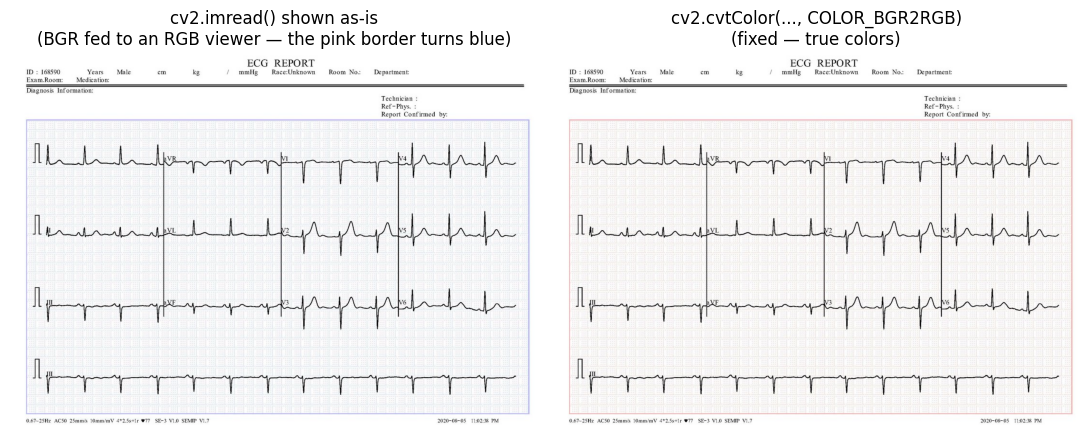

In [2]:
sample_path = os.path.join(IMAGE_DIR, labels_df.loc[0, "filename"])
img_bgr = cv2.imread(sample_path)

print("Shape:", img_bgr.shape, " dtype:", img_bgr.dtype, " (H, W, Channels)")
print("OpenCV's default channel order is BGR, not RGB.")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(img_bgr)
axes[0].set_title("cv2.imread() shown as-is\n(BGR fed to an RGB viewer — the pink border turns blue)")
axes[0].axis("off")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
axes[1].imshow(img_rgb)
axes[1].set_title("cv2.cvtColor(..., COLOR_BGR2RGB)\n(fixed — true colors)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("bgr_vs_rgb.png", dpi=130)
plt.show()

> [!WARNING]
> **The fix:** always convert with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` immediately after `cv2.imread`. This is
> Day 3's version of Day 1's dropped `"not"` and Day 2's TF-IDF choice — a one-line detail that's easy to skip and
> silently wrong until someone actually checks the output.

## 3.3 &nbsp;The Preprocessing Pipeline

With the color-space bug fixed, two more decisions turn this into a real pipeline — and the *right* choice for each
one depends on what these scans actually are, not on a generic CV checklist:

- **Resize** to a consistent shape — every model needs a fixed input size, and every scan needs to end up at the
  same one.
- **Grayscale, not color.** Unlike a skin-lesion photo (where color is literally diagnostic — the "C" in ABCDE), an
  ECG report's signal lives entirely in the *shape* of the traced line against the grid. The paper's pink
  calibration tint and the printer's ink color carry no clinical meaning. Converting to grayscale here throws away
  noise, not signal — the opposite conclusion from a task where color *is* the label.

Processed 12 scans
Shape: (424, 600)  dtype: float32  value range: [0.00, 1.00]


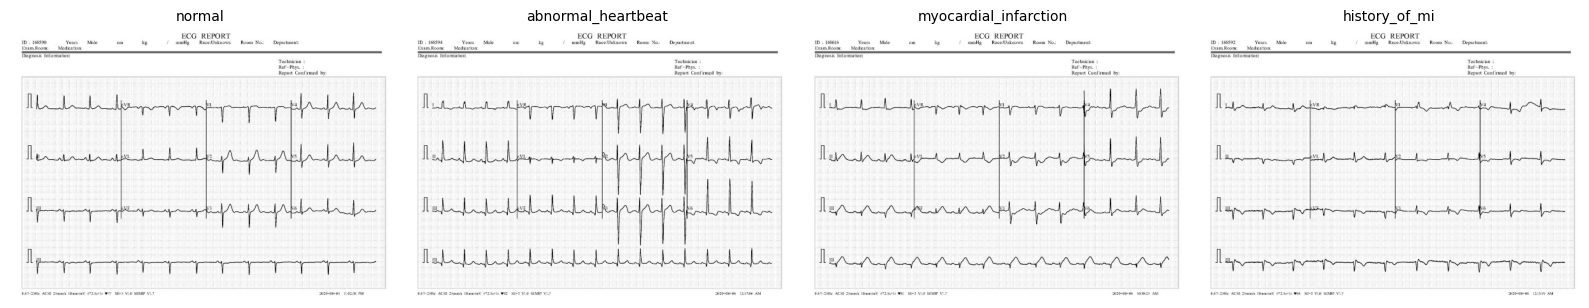

In [3]:
IMG_SIZE = (600, 424)  # consistent input shape, aspect-ratio-matched to these scans

def preprocess_scan(path, size=IMG_SIZE):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)         # fix channel order
    img_resized = cv2.resize(img_rgb, size)                     # consistent input shape
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)    # color carries no signal here
    img_normalized = img_gray.astype(np.float32) / 255.0        # scale 0-255 -> 0.0-1.0
    return img_normalized

processed = [preprocess_scan(os.path.join(IMAGE_DIR, f)) for f in labels_df["filename"]]

sample = processed[0]
print(f"Processed {len(processed)} scans")
print(f"Shape: {sample.shape}  dtype: {sample.dtype}  value range: [{sample.min():.2f}, {sample.max():.2f}]")

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
one_per_class = labels_df.groupby("label").head(1).index
for ax, idx in zip(axes, one_per_class):
    ax.imshow(processed[idx], cmap="gray")
    ax.set_title(labels_df.loc[idx, "label"], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("preprocessed_grid.png", dpi=130)
plt.show()

## 3.4 &nbsp;Data Augmentation

With only a handful of scans per class, a CNN could memorize the training set instead of learning general patterns.
**Augmentation** manufactures realistic variations on the fly — but "realistic" is doing a lot of work in that
sentence, and it means something very different here than it did for a skin-lesion photo.

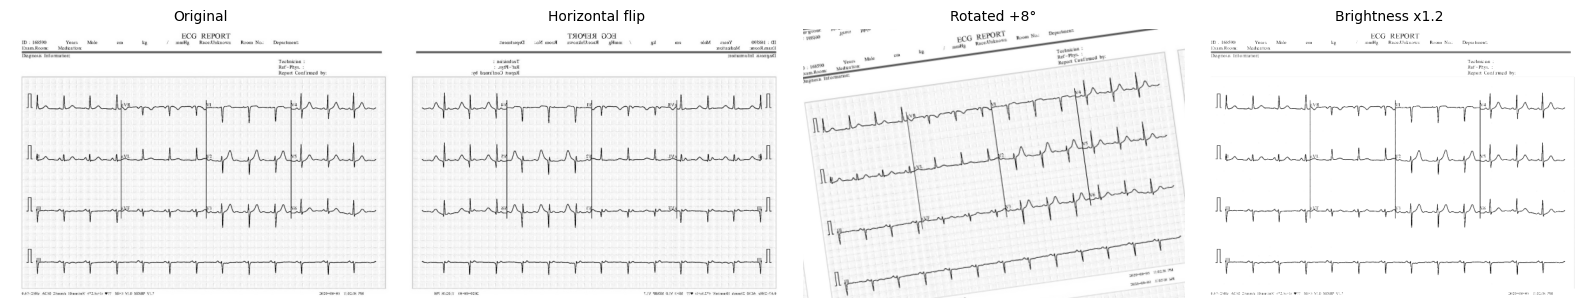

In [4]:
def augment_flip(img):
    return cv2.flip(img, 1)  # horizontal flip

def augment_rotate(img, angle=8):
    h, w = img.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)

def augment_brightness(img, factor=1.2):
    return np.clip(img * factor, 0.0, 1.0)

original = processed[0]
augmented = {
    "Original": original,
    "Horizontal flip": augment_flip(original),
    "Rotated +8°": augment_rotate(original, 8),
    "Brightness x1.2": augment_brightness(original, 1.2),
}

fig, axes = plt.subplots(1, len(augmented), figsize=(16, 4.5))
for ax, (title, img) in zip(axes, augmented.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("augmentation_grid.png", dpi=130)
plt.show()

### ⚖️ Which augmentations are safe *for this task*? (Compare to Day 3's melanoma draft — the answer flips)

| Augmentation | Safe for a 12-lead ECG scan? | Why |
|---|---|---|
| Horizontal flip | 🚫 **No** | Time runs left-to-right on an ECG strip. Flipping it reverses the P-QRS-T sequence — the model would be trained on a signal that runs backward in time, which is not a variation a real scan ever has. |
| Vertical flip | 🚫 **No** | Flips the polarity of every lead. An upright R wave becomes an inverted one — this can turn a normal-looking beat into a shape associated with a completely different diagnosis. |
| Rotation beyond a few degrees | ⚠️ **Risky** | The grid lines encode calibrated time (mm/s) and voltage (mm/mV). Any rotation that isn't tiny distorts the exact measurements the diagnosis depends on — unlike a lesion photo, where rotation is free because there's no calibrated grid to distort. |
| Mild brightness / contrast jitter | ✅ **Yes** | Mimics realistic scan/lighting variation across different clinics' printers and scanners, without touching the waveform itself. |
| Small, label-preserving crop (keeping all 12 leads visible) | ✅ **Yes, with care** | Simulates minor framing differences during scanning — as long as no lead panel is cut off. |

This is the opposite conclusion from the melanoma-style photo case: there, flips and rotation were free and color was
the risk; here, color is free and flips/rotation are the risk. Neither table is "the augmentation rules for images" —
each one is what happens when the same generic toolbox (`cv2.flip`, `cv2.warpAffine`, brightness scaling) gets
checked against what a *specific* image format actually encodes.

## 🧪 Hands-On Lab: Image Preprocessing & Augmentation

| Step | Task | Status |
|---|---|---|
| 1 | Load a real scan with OpenCV, catch and fix the BGR/RGB bug | ✅ done above (§3.2) |
| 2 | Build a resize + grayscale + normalize preprocessing pipeline | ✅ done above (§3.3) |
| 3 | Apply and visualize augmentation (flip, rotate, brightness) | ✅ done above (§3.4) |
| 4 | Document which augmentations are safe for this domain, and why | ✅ done above (§3.4) |

### 📝 Documentation: preprocessing choices for the Cardiac Monitoring thread

- **This is the first Sprint 3 notebook that runs on the capstone's own clinical modality.** Day 1 and Day 2 borrowed
  the UCI Drug Review dataset for text practice; the first cut of Day 3 borrowed Week 7's melanoma images. This
  version runs on real 12-lead ECG scans — the same signal type the Cardiac Monitoring project ultimately cares
  about, even though the capstone's current model consumes structured vitals (`heart.csv`), not images.
- **If the capstone ever ingested scanned ECG reports directly** (instead of, or alongside, tabular vitals), this is
  the exact pipeline it would need: BGR→RGB, resize, grayscale, normalize, and augmentation restricted to
  brightness/contrast and careful cropping — never flips or real rotation.
- **The recurring theme across all of Sprint 3:** every representation choice this week — negation-aware stop words,
  TF-IDF vs. embeddings, and now grayscale-vs-color and safe-vs-unsafe augmentation — looks like a minor technical
  detail right up until it quietly flips the label the model is supposed to predict.

<div style="display:flex; flex-wrap:wrap; gap:8px; margin:18px 0;">
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🖼️ OpenCV (cv2)</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🔢 NumPy</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📊 Matplotlib</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📓 Jupyter / Colab</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🔗 Git &amp; GitHub</span>
</div>

<div style="background:linear-gradient(135deg,#0B2E59,#061A33); border-radius:14px; padding:24px 28px; color:#EAF6FA; margin-top:10px;">
<h3 style="margin-top:0; color:#8CE9F4;">✅ Day 3 — Closed Out</h3>
<p style="line-height:1.6;">
Images now go through the same discipline text did on Day 1 and Day 2 — on real 12-lead ECG scans from the exact
clinical domain this capstone lives in. A real bug caught and fixed (BGR vs. RGB), and augmentation choices reasoned
out from what these scans actually encode, not copied from a generic tutorial — flips and rotation are the risk here,
where they were free for a photo dataset. Tomorrow (<b>Day 4</b>) all of this gets wired into a single end-to-end
<code>predict()</code> pipeline, plus the sprint's first real error analysis.
</p>
<div style="text-align:right; font-size:13px; opacity:0.7; margin-top:10px;">Week 8 · Sprint 3 · Day 3 of 5 → <b>Day 4: End-to-End predict() Pipeline &amp; Error Analysis</b></div>
</div>